## Xray Lung Classifier 

---
### Project flow  

1) Importing the libraries and Loading the Images

2) Exploring the Images and transforming the Images

3) Creating the model Architecture

4) Training the Data

5) Evaluate the Model 

---
### Importing the libraries and Loading the Images

In [22]:
import os
import numpy as np
import cv2    # opencv-python to be installed
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
from PIL import Image
from IPython.display import display
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import StepLR
from torchsummary import summary
from tqdm import tqdm

In [23]:
#data path where images are stored
data_path = 'D:\dk\data_science\DL\projects\my_lung_diseases\data'

---
### Exploring the Images and transforming the Images

In [24]:
# Defining the class name 
class_name = ['NORMAL','PNEUMONIA']

# Creating a function to  get the list of files
def get_list_of_files(dir_name):
    '''
    input - The input directory location
    output - Returns the list the files in the directory
    '''
    files_list = os.listdir(dir_name)#getting the list of files
    return files_list


In [25]:
files_list_normal_train = get_list_of_files(data_path+'/train/'+class_name[0])

files_list_pneumonia_train = get_list_of_files(data_path+'/train/'+class_name[1])

files_list_normal_test = get_list_of_files(data_path+'/test/'+class_name[0])

files_list_pneumonia_test = get_list_of_files(data_path+'/test/'+class_name[1])

In [26]:
print("Number of train samples in Normal category {}".format(len(files_list_normal_train)))
print("Number of train samples in Pneumonia category {}".format(len(files_list_pneumonia_train)))
print("Number of test samples in Normal category {}".format(len(files_list_normal_test)))
print("Number of test samples in Pneumonia category {}".format(len(files_list_pneumonia_test)))

Number of train samples in Normal category 1266
Number of train samples in Pneumonia category 3418
Number of test samples in Normal category 317
Number of test samples in Pneumonia category 855


---
### Exploring the images 

- Let's print the Normal and Pneumonia images from Training folder 

(1437, 1820, 3)


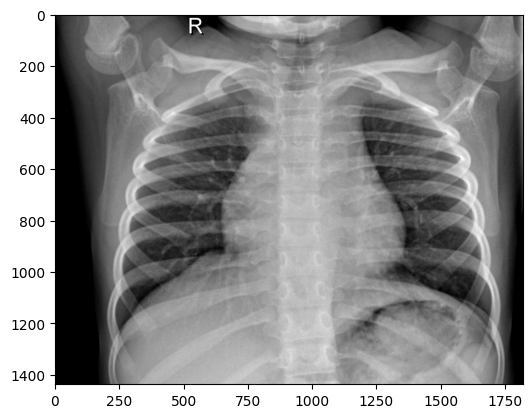

In [27]:
rand_img_no = np.random.randint(0, len(files_list_normal_train))
img = data_path+ '/train/NORMAL/'+files_list_normal_train[rand_img_no]
img = mpimg.imread(img)#mpimg.imread(img)→ reads image as a NumPy array, (height, width, channels)
print(img.shape)
imgplot = plt.imshow(img)
plt.show()

(1136, 1736, 3)


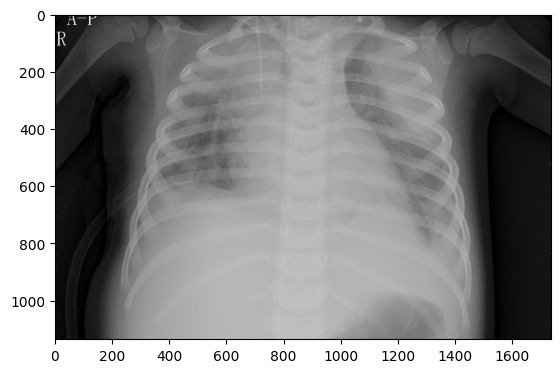

In [28]:
img = data_path+'/train/PNEUMONIA/'+files_list_pneumonia_train[np.random.randint(0, len(files_list_pneumonia_train))]
img = mpimg.imread(img)
print(img.shape)
imgplot = plt.imshow(img)
plt.show()

### Insights 

- If we run the above cell mutiple times we can see that the images are of different shapes for the 'NORMAL' and 'PNEUMONIA' images in the **train** folder.

(1216, 1400, 3)


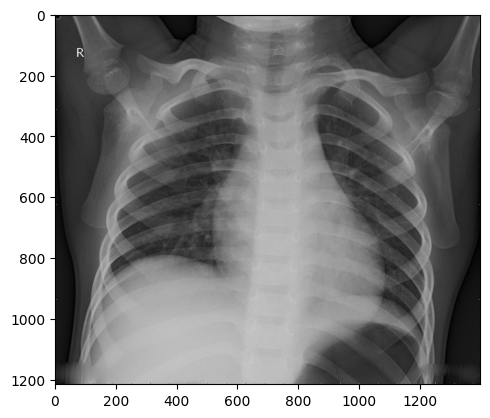

In [29]:
rand_img_no = np.random.randint(0, len(files_list_normal_test))
img = data_path+'/test/NORMAL/'+files_list_normal_test[rand_img_no]
img = mpimg.imread(img)
print(img.shape)
imgplot = plt.imshow(img)
plt.show()

(664, 904, 3)


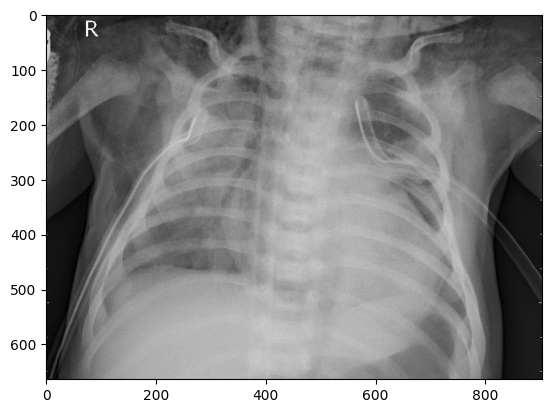

In [30]:
img = data_path + '/test/PNEUMONIA/'+ files_list_pneumonia_test[np.random.randint(0,len(files_list_pneumonia_test))]
img = mpimg.imread(img)
print(img.shape)
imgplot = plt.imshow(img)
plt.show()

### Insights 

- If we run the above cell mutiple times we can see that the images are of different shapes for the 'NORMAL' and 'PNEUMONIA' images in the **test** folder.

### Transforming the Images 

- Now that we have seen the sample of the images let's transform the data now 
- We need to perform transformation on both train and test images 
- For Training data we need to perform the data augmentation also.
- Data Augmentation is done to create synthetic data.
- augmentation >>  What is Data Augmentation?>> Data augmentation means creating new training images from existing images by applying small random changes.
- **We perform image transformations to standardize input size, convert images into tensors, normalize pixel values, and apply data augmentation during training to reduce overfitting and improve model generalization.”**

**“Transforms prepare images for the model and help it learn better.”**


In **Transformation** we are doing Resize,CenterCrop,ColorJitter,RandomHorizontalFlip,RandomRotation,ToTensor and Normalize.

- Resize:- Resize the input image to the given size.
- CenterCrop:- Crops the given image at the center.
- ColorJitter:- Randomly change the brightness, contrast, saturation and hue of an image.
- RandomHorizontalFlip:- Horizontally flip the given image randomly with a given probability.
- RandomRotation:- Rotate the image by angle.
- ToTensor:- Convert numpy.ndarray to tensor.
- Normalize:- Normalize a float tensor image with mean and standard deviation.

In [31]:
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ColorJitter(brightness=0.10, contrast=0.1, saturation=0.10, hue=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],#mean values
                          [0.229, 0.224, 0.225])#std deviation values
])
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225])
])


### Creating Data Loader

- For our usecase will be using the default data loader for Pytorch.
- We will be creating 2 data loaders one for the training data and other for the test data.
- batch size is a hyperparameter which we can tweak according to our need and system configuration.
- We can provide Image shuffling True for training data and False for test data.
- Pin memory is used to transfer the loaded dataset from CPU to GPU. 
- datasets.ImageFolder is a PyTorch Dataset class that loads images from class-wise folders and automatically assigns labels.

In [32]:
train_data = datasets.ImageFolder(os.path.join(data_path, 'train'), transform= train_transform)
test_data = datasets.ImageFolder(os.path.join(data_path, 'test'), transform= test_transform)
train_loader = DataLoader(train_data,
                          batch_size= 2, shuffle= True, pin_memory= True)##2 images per batch, Model processes 2 images at once
test_loader = DataLoader(test_data,
                         batch_size= 2, shuffle= False, pin_memory= True)
class_names = train_data.classes
print(class_names)
print(f'Number of train images: {len(train_data)}')
print(f'Number of test images: {len(test_data)}')

['COVID19', 'NORMAL', 'PNEUMONIA']
Number of train images: 5144
Number of test images: 1288


---
### Creating the model Architecture

- First Layer is the **input layer** consisting of 3 input channels and output channels with kernel_size of 3X3, padding=0 and bias=True. The activation function we are using is ReLU and performing batch normalization.
- Then we are performing max pooling to extract the important features out of the image.
- Similarly we are passing our model through 9 convolutional layers.
- Finally we are passing out passing our model through a output layer in which we are getting binary classification.


In [33]:
class Net(nn.Module):
    def __init__(self, num_classes=2):
        """
        Creating custom CNN architecture for Image classification
        """
        super(Net, self).__init__()
        self.num_classes = num_classes
        # Input Block
        self.convolution_block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=(3, 3),
                      padding=0, bias=True),
                        
            nn.ReLU(),
            nn.BatchNorm2d(8)
        )
        self.pooling11 = nn.MaxPool2d(2, 2)
        # CONVOLUTION BLOCK 1
        self.convolution_block2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=20, kernel_size=(3, 3),
                      padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(20)
        )
        self.pooling22 = nn.MaxPool2d(2, 2)
        self.convolution_block3 = nn.Sequential(
            nn.Conv2d(in_channels=20, out_channels=10, kernel_size=(1, 1), padding=0, bias=True),#Number of filters → Number of feature maps → Number of output channels
            nn.ReLU(),                                                                           

            nn.BatchNorm2d(10),
        )
        self.pooling33 = nn.MaxPool2d(2, 2)
        
        # CONVOLUTION BLOCK 2
        self.convolution_block4 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=20, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(20)
        )
        self.convolution_block5 = nn.Sequential(
            nn.Conv2d(in_channels=20, out_channels=32, kernel_size=(1, 1), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(32),
        )
#         self.convblock6 = nn.Sequential(
#             nn.Conv2d(in_channels=32, out_channels=10, kernel_size=(1, 1), padding='same', bias=True),
#             nn.ReLU(),
#             nn.BatchNorm2d(10),
#         )
        self.convolution_block6 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=10, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
#         self.convblock8 = nn.Sequential(
#             nn.Conv2d(in_channels=10, out_channels=32, kernel_size=(1, 1), padding='same', bias=True),
#             nn.ReLU(),
#             nn.BatchNorm2d(32)
#         )
        self.convolution_block7 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=10, kernel_size=(1, 1), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
        self.convolution_block8 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=14, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(14)
        )
        self.convolution_block9 = nn.Sequential(
            nn.Conv2d(in_channels=14, out_channels=16, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(16)
        )
        # OUTPUT BLOCK
        self.gap = nn.Sequential(
            nn.AvgPool2d(kernel_size=4)
        )#GAP = Global Average Pooling Usually applied when feature map size is 4×4
         #At that stage, the network has already extracted “WHAT” is present in the image,
        #so GAP summarizes it instead of preserving “WHERE” it is.
        self.convolution_block_out = nn.Sequential(
              nn.Conv2d(in_channels=16, out_channels=self.num_classes, kernel_size=(4, 4), padding=0, bias=True),
        )
    def forward(self, x):#forward propagation
        x = self.convolution_block1(x)
        x = self.pooling11(x)
        x = self.convolution_block2(x)
        x = self.pooling22(x)
        x = self.convolution_block3(x)
        x = self.pooling33(x)
        x = self.convolution_block4(x)
        x = self.convolution_block5(x)
#         x = self.convblock6(x)
        x = self.convolution_block6(x)
#         x = self.convblock8(x)
        x = self.convolution_block7(x)
        x = self.convolution_block8(x)
        x = self.convolution_block9(x)
        x = self.gap(x)
        x = self.convolution_block_out(x)
        x = x.view(-1, self.num_classes)  # reshape to match number of classes
        return x # it contains raw class scores, not probabilities 

In [34]:
import numpy as np

In [35]:
# To check weather cuda is available in the system or not 
use_cuda = torch.cuda.is_available()
device = torch.device('cuda' if use_cuda else 'cpu')
print('available prcessor:{}'.format(device))
model = Net(num_classes=len(class_names)).to(device)

# To check the model summary
summary(model, input_size=(3, 224, 224))
                                        

available prcessor:cpu
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 222, 222]             224
              ReLU-2          [-1, 8, 222, 222]               0
       BatchNorm2d-3          [-1, 8, 222, 222]              16
         MaxPool2d-4          [-1, 8, 111, 111]               0
            Conv2d-5         [-1, 20, 109, 109]           1,460
              ReLU-6         [-1, 20, 109, 109]               0
       BatchNorm2d-7         [-1, 20, 109, 109]              40
         MaxPool2d-8           [-1, 20, 54, 54]               0
            Conv2d-9           [-1, 10, 54, 54]             210
             ReLU-10           [-1, 10, 54, 54]               0
      BatchNorm2d-11           [-1, 10, 54, 54]              20
        MaxPool2d-12           [-1, 10, 27, 27]               0
           Conv2d-13           [-1, 20, 25, 25]           1,820
             ReL

---
### Training the Data

In [36]:
#traning the data
train_losses=[]
test_losses =[]
train_acc = []
test_acc = []

def train(model, device, train_loader, optimizer, epoch, criterion):
    model.train()
    pbar = tqdm(train_loader)
    processed = 0
    correct =0
    
    for batch_ind, (data, target) in enumerate(pbar):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()#It clears (resets) all previously calculated gradients before the next backpropagation step
        # or specific requirements
        
        ## prediction on data
        y_pred = model(data)
        
        #calculating loss given prediction 
        loss = criterion(y_pred, target)
        train_losses.append(loss.item())
        
        #backpropagation
        loss.backward()#calculating gradiants
        optimizer.step()# update the model’s weights using the gradients computed during loss.backward().

        
        # get the index of the log-probability corresponding to the max value
        pred = y_pred.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        processed += len(data)#counts how many input samples (images) have been processed so far, len(data) = batch size
        pbar.set_description(desc=f'Loss {loss.item():.4f} batch_id = {batch_ind} accuracy = {100*correct/processed:02.0f}')
        train_acc.append(100*correct/processed)
            


In [37]:
def test(model, device, test_loader, criterion):
    """
    Description: To test the model
    
    input: model, device, test_loader
    
    output: average loss and accuracy
    
    """
    model.eval()
    
    test_loss = 0
    correct = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.cross_entropy(output, target, reduction='sum').item()
    test_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)
    print('\ntest set: average loss: {:.4f}, accuracy: {}/{} ({:.2f}%)\n'.format(test_loss, correct, len(test_loader.dataset), 100* correct/len(test_loader.dataset)))
    test_acc.append(100. * correct / len(test_loader.dataset))


In [38]:
num_classes = len(class_names)
model = Net(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()#Cross-Entropy Loss measures how well the predicted probability distribution matches the true class, ❝It checks how confident the model is about the correct class❞
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.08)
scheduler = StepLR(optimizer, step_size=6, gamma=0.5)
EPOCHS = 13

for epoch in range(EPOCHS):
    print('EPOCH', epoch)
    train(model, device, train_loader, optimizer, epoch, criterion)
    scheduler.step()

    print('current learning rate ', optimizer.state_dict()['param_groups'][0]['lr'])    
    test(model, device, test_loader, criterion)

EPOCH 0


  0%|          | 0/2572 [00:00<?, ?it/s]c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Loss 0.1928 batch_id = 2571 accuracy = 85: 100%|██████████| 2572/2572 [04:42<00:00,  9.09it/s]


current learning rate  0.01

test set: average loss: 0.3281, accuracy: 0/1288 (0.00%)

EPOCH 1


Loss 0.0485 batch_id = 2571 accuracy = 89: 100%|██████████| 2572/2572 [03:49<00:00, 11.22it/s]


current learning rate  0.01

test set: average loss: 0.4097, accuracy: 0/1288 (0.00%)

EPOCH 2


...

current learning rate  0.005

test set: average loss: 0.1691, accuracy: 0/1288 (0.00%)

EPOCH 11


Loss 0.0740 batch_id = 2571 accuracy = 94: 100%|██████████| 2572/2572 [03:41<00:00, 11.59it/s]


current learning rate  0.0025

test set: average loss: 0.1537, accuracy: 0/1288 (0.00%)

EPOCH 12


Loss 0.1087 batch_id = 2571 accuracy = 95: 100%|██████████| 2572/2572 [03:39<00:00, 11.72it/s]


current learning rate  0.0025

test set: average loss: 0.1562, accuracy: 0/1288 (0.00%)



### Evaluate the Model 

- Plotting the graph for taining loss and training accuracy
- Plotting the graph for test loss and test accuracy 

Text(0.5, 1.0, 'Test Accuracy')

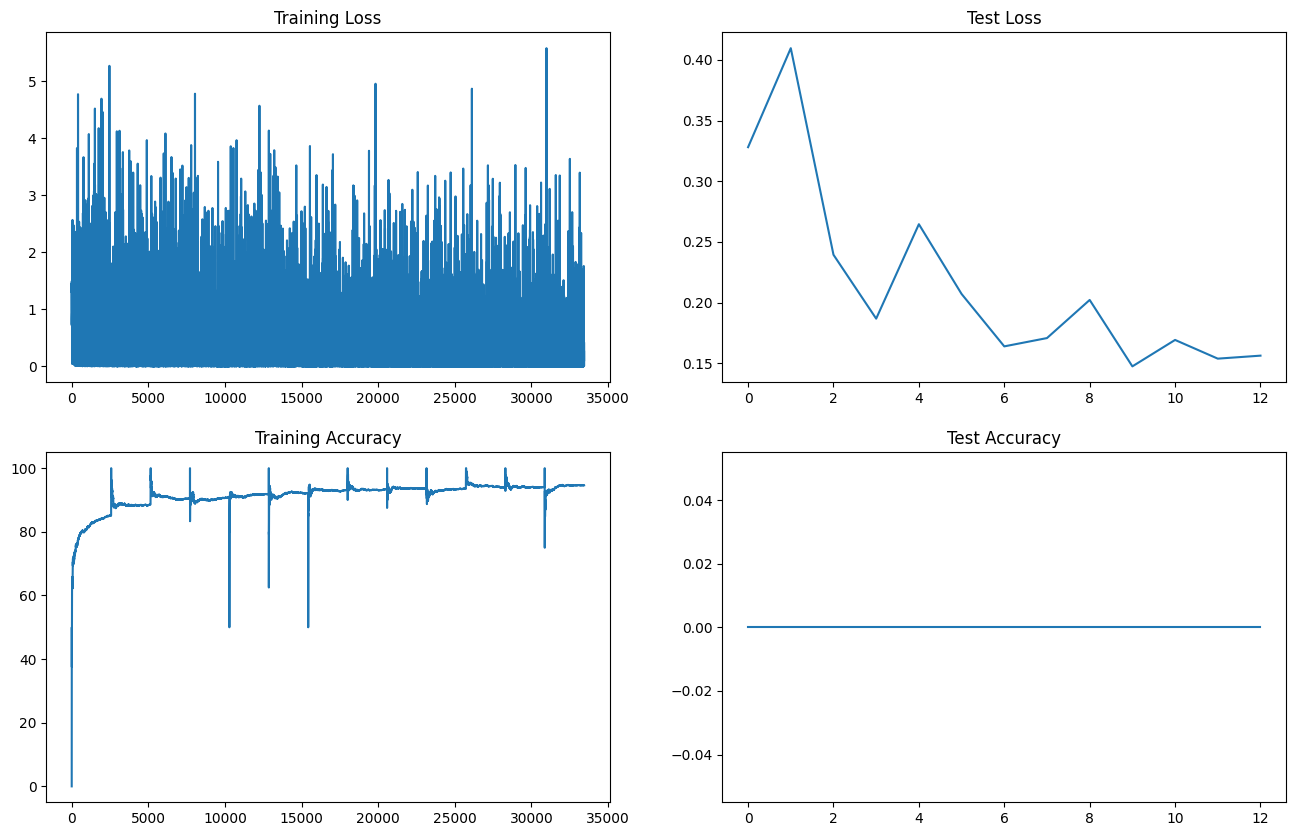

In [39]:
train_losses1 = train_losses
train_acc1 = train_acc
test_losses1 = test_losses
test_acc1 = test_acc

fig, axs = plt.subplots(2,2,figsize=(16,10))

axs[0, 0].plot(train_losses1)
axs[0, 0].set_title("Training Loss")

axs[1, 0].plot(train_acc1)
axs[1, 0].set_title("Training Accuracy")

axs[0, 1].plot(test_losses1)
axs[0, 1].set_title("Test Loss")

axs[1, 1].plot(test_acc1)
axs[1, 1].set_title("Test Accuracy")


### Insights

- As we can see from the above graph that training loss has many fluctuation at the start but then it consolidates over a period of time.
- From the training accuracy graph we are able to get a training accuracy of around 50% throughout
- Test loss graph decreases as the number of epochs increases.
- test accuracy remains constant at around 50%.

In [40]:
torch.save(model.state_dict(), "xray_model.pth")